# Deteksi Kecanduan Smartphone Menggunakan XGBoost
**Jurnal Sinta 3 — Machine Learning Pipeline**

**Alur Penelitian:**
1. Data Loading & Eksplorasi Awal
2. Data Cleaning & Pre-processing
3. Feature Engineering
4. Deteksi Target Leakage
5. Data Splitting & Feature Scaling
6. Penanganan Class Imbalance (SMOTE)
7. Pemodelan & Training XGBoost
8. Evaluasi Model & Deteksi Overfitting
9. Prediksi pada Data Uji
10. Visualisasi (Feature Importance, SHAP, Learning Curve, ROC-AUC)

---
## 0. Import Library & Setup

In [1]:
# ==========================================
# 0. IMPORT LIBRARY & GLOBAL SETUP
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE

import xgboost as xgb
import shap

import warnings
warnings.filterwarnings('ignore')

# Setup tema plot konsisten untuk jurnal
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold'
})

RANDOM_STATE = 42
print("✅ Semua library berhasil diimport.")

✅ Semua library berhasil diimport.


c:\Conda\envs\findit\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 1. Data Loading & Eksplorasi Awal

In [2]:
# ==========================================
# 1. LOAD DATA & EKSPLORASI AWAL
# ==========================================
FILE_PATH = 'E:\\Python - Project\\phone-addiction-detection\\Data\\Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv'
df_raw = pd.read_csv(FILE_PATH)

print(f"✅ Dataset berhasil dimuat!")
print(f"   Dimensi: {df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom\n")
print("=" * 50)
print("INFO KOLOM:")
print("=" * 50)
df_raw.info()

✅ Dataset berhasil dimuat!
   Dimensi: 7,500 baris × 16 kolom

INFO KOLOM:
<class 'pandas.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   str    
 1   user_id                  7500 non-null   str    
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   str    
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   str    
 13  academic_work_

In [3]:
# Sampel data awal
print("SAMPEL DATA (5 baris pertama):")
display(df_raw.head())

print("\nSTATISTIK DESKRIPTIF (FITUR NUMERIK):")
display(df_raw.describe().round(2))

SAMPEL DATA (5 baris pertama):


,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1



STATISTIK DESKRIPTIF (FITUR NUMERIK):


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.00,7500.00,7500.00,7500.00,7500.00,7500.00,7500.00,7500.00,7500.00,7500.00
mean,26.57,7.50,3.27,2.01,3.24,6.74,134.26,97.83,9.24,0.71
std,5.20,2.61,1.59,1.15,1.60,1.28,66.59,48.42,2.72,0.45
min,18.00,3.00,0.50,0.00,0.50,4.50,20.00,15.00,3.58,0.00
25%,22.00,5.22,1.91,1.02,1.85,5.63,76.00,55.00,6.96,0.00
50%,27.00,7.52,3.27,2.04,3.23,6.72,134.00,98.00,9.26,1.00
75%,31.00,9.81,4.63,2.99,4.64,7.84,191.00,140.00,11.54,1.00
max,35.00,12.00,6.00,4.00,6.00,9.00,250.00,180.00,14.88,1.00


In [4]:
# Cek Missing Values
print("=== ANALISIS MISSING VALUES ===")
missing = pd.DataFrame({
    'Total Kosong': df_raw.isnull().sum(),
    'Persentase (%)': (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
})
missing_nonzero = missing[missing['Total Kosong'] > 0]

if len(missing_nonzero) > 0:
    display(missing_nonzero)
    print("\n⚠️  Ditemukan missing values pada kolom di atas.")
    print("   → 'addiction_level' akan di-drop (target leakage). Missing value tidak perlu diimputasi.")
else:
    print("✅ Dataset bersih: tidak ada missing values.")

# Cek Duplikat
n_dup = df_raw.duplicated().sum()
print(f"\n=== CEK DUPLIKAT ===")
print(f"Jumlah baris duplikat: {n_dup}")
print("✅ Tidak ada duplikat." if n_dup == 0 else f"⚠️  Terdapat {n_dup} baris duplikat → akan di-drop.")

=== ANALISIS MISSING VALUES ===


,Total Kosong,Persentase (%)
addiction_level,819,10.92



⚠️  Ditemukan missing values pada kolom di atas.
   → 'addiction_level' akan di-drop (target leakage). Missing value tidak perlu diimputasi.

=== CEK DUPLIKAT ===
Jumlah baris duplikat: 0
✅ Tidak ada duplikat.


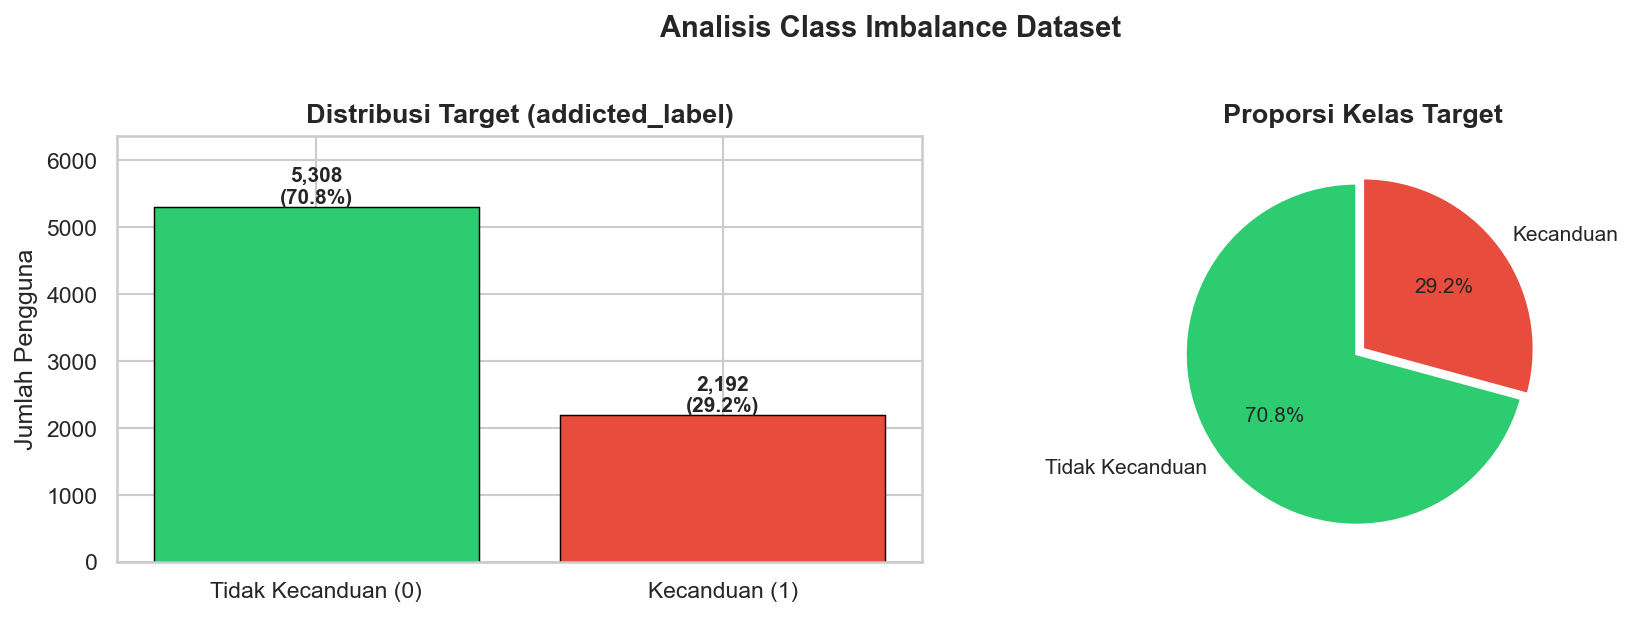


⚠️  Rasio kelas: 2.42:1 (Kecanduan vs Tidak Kecanduan)
   → Class imbalance terdeteksi. Akan ditangani dengan SMOTE pada data latih.


In [ ]:
# Visualisasi Distribusi Target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart distribusi kelas
vc = df_raw['addicted_label'].value_counts()
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(['Tidak Kecanduan (0)', 'Kecanduan (1)'], vc.values, color=colors, edgecolor='black', linewidth=0.7)
for bar, val in zip(bars, vc.values):
    pct = val / len(df_raw) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Distribusi Target (addicted_label)')
axes[0].set_ylabel('Jumlah Pengguna')
axes[0].set_ylim(0, max(vc.values) * 1.2)

# Pie chart
axes[1].pie(vc.values, labels=['Tidak Kecanduan', 'Kecanduan'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            explode=[0.05, 0], textprops={'fontsize': 10})
axes[1].set_title('Proporsi Kelas Target')

plt.suptitle('Analisis Class Imbalance Dataset', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig1_distribusi_target.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"\n⚠️  Rasio kelas: {vc[1]/vc[0]:.2f}:1 (Kecanduan vs Tidak Kecanduan)")
print("   → Class imbalance terdeteksi. Akan ditangani dengan SMOTE pada data latih.")

---
## 2. Deteksi Target Leakage

> **Penting:** `addiction_level` adalah kolom yang secara konseptual **derivasi langsung** dari `addicted_label`. Memasukkannya ke dalam model akan menyebabkan kebocoran data (*data leakage*) yang membuat akurasi palsu mendekati 100%. Kolom ini **wajib dihapus**.

In [ ]:
# ==========================================
# 2. DETEKSI TARGET LEAKAGE
# ==========================================
print("=== ANALISIS TARGET LEAKAGE ===")

# -- Bukti 1: Cross-tabulation addiction_level vs addicted_label --
if 'addiction_level' in df_raw.columns:
    ct = pd.crosstab(df_raw['addiction_level'], df_raw['addicted_label'],
                    margins=True, margins_name='Total')
    print("\n[BUKTI 1] Cross-Tabulation addiction_level vs addicted_label:")
    display(ct)
    print("\n→ Terlihat: 'Moderate' & 'Severe' SELALU berlabel 1 (Kecanduan).")
    print("→ 'Mild' SELALU berlabel 0 (Tidak Kecanduan).")
    print("→ KESIMPULAN: addiction_level adalah proxy langsung dari addicted_label = TARGET LEAKAGE!")

# -- Bukti 2: Korelasi numerik (setelah di-encode sementara) --
print("\n[BUKTI 2] Korelasi Fitur Numerik dengan Target (threshold > 0.85):")
df_temp = df_raw.copy()
if 'addiction_level' in df_temp.columns:
    df_temp['addiction_level_enc'] = df_temp['addiction_level'].map({'Mild': 1, 'Moderate': 2, 'Severe': 3})
korr = df_temp.select_dtypes(include=np.number).corr()['addicted_label'].abs().sort_values(ascending=False)
bocor = korr[(korr > 0.85) & (korr.index != 'addicted_label')]
if len(bocor) > 0:
    for f, v in bocor.items():
        print(f"   ⚠️  LEAKAGE TERDETEKSI: '{f}' | korelasi = {v:.4f}")
else:
    print("   ✅ Tidak ada fitur lain dengan korelasi > 0.85 (selain addiction_level).")

print("\n✅ TINDAKAN: 'transaction_id', 'user_id', dan 'addiction_level' akan di-DROP sebelum training.")

=== ANALISIS TARGET LEAKAGE ===

[BUKTI 1] Cross-Tabulation addiction_level vs addicted_label:


addicted_label,0,1,Total
addiction_level,,,
Mild,1373,0,1373
Moderate,0,2874,2874
Severe,0,2434,2434
Total,1373,5308,6681



→ Terlihat: 'Moderate' & 'Severe' SELALU berlabel 1 (Kecanduan).
→ 'Mild' SELALU berlabel 0 (Tidak Kecanduan).
→ KESIMPULAN: addiction_level adalah proxy langsung dari addicted_label = TARGET LEAKAGE!

[BUKTI 2] Korelasi Fitur Numerik dengan Target (threshold > 0.85):
   ✅ Tidak ada fitur lain dengan korelasi > 0.85 (selain addiction_level).

✅ TINDAKAN: 'transaction_id', 'user_id', dan 'addiction_level' akan di-DROP sebelum training.


---
## 3. Data Cleaning & Pre-processing

In [7]:
# ==========================================
# 3. DATA CLEANING
# ==========================================
df = df_raw.copy()

# -- 3.1 Hapus duplikat (jika ada) --
before = len(df)
df.drop_duplicates(inplace=True)
print(f"[3.1] Drop duplikat: {before - len(df)} baris dihapus. Sisa: {len(df):,} baris.")

# -- 3.2 Drop kolom tidak relevan & leakage --
#   'transaction_id', 'user_id'  → ID, tidak punya pola prediktif
#   'addiction_level'            → TARGET LEAKAGE (sudah dibuktikan di atas)
COLS_DROP = ['transaction_id', 'user_id', 'addiction_level']
df.drop(columns=COLS_DROP, inplace=True, errors='ignore')
print(f"[3.2] Drop kolom: {COLS_DROP}")
print(f"      Kolom tersisa: {df.columns.tolist()}")

# -- 3.3 Validasi tipe data & range nilai --
print("\n[3.3] Validasi range nilai fitur numerik:")
num_cols = ['age', 'daily_screen_time_hours', 'social_media_hours',
            'gaming_hours', 'work_study_hours', 'sleep_hours',
            'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']

valid_ranges = {
    'age': (10, 100),
    'daily_screen_time_hours': (0, 24),
    'social_media_hours': (0, 24),
    'gaming_hours': (0, 24),
    'work_study_hours': (0, 24),
    'sleep_hours': (0, 24),
    'notifications_per_day': (0, 2000),
    'app_opens_per_day': (0, 1000),
    'weekend_screen_time': (0, 24)
}
for col, (lo, hi) in valid_ranges.items():
    n_invalid = ((df[col] < lo) | (df[col] > hi)).sum()
    status = '✅' if n_invalid == 0 else f'⚠️  {n_invalid} nilai anomali'
    print(f"   {col}: [{lo}, {hi}] → {status}")

# -- 3.4 Deteksi Outlier (IQR Method) --
print("\n[3.4] Deteksi Outlier (Metode IQR):")
total_outlier = 0
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    total_outlier += n_out
    if n_out > 0:
        print(f"   ⚠️  {col}: {n_out} outlier")
if total_outlier == 0:
    print("   ✅ Dataset bebas outlier ekstrem.")
else:
    print(f"\n   Catatan: XGBoost robust terhadap outlier → tidak perlu di-clip/remove.")

print(f"\n✅ Cleaning selesai. Dimensi akhir: {df.shape}")

[3.1] Drop duplikat: 0 baris dihapus. Sisa: 7,500 baris.
[3.2] Drop kolom: ['transaction_id', 'user_id', 'addiction_level']
      Kolom tersisa: ['age', 'gender', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'stress_level', 'academic_work_impact', 'addicted_label']

[3.3] Validasi range nilai fitur numerik:
   age: [10, 100] → ✅
   daily_screen_time_hours: [0, 24] → ✅
   social_media_hours: [0, 24] → ✅
   gaming_hours: [0, 24] → ✅
   work_study_hours: [0, 24] → ✅
   sleep_hours: [0, 24] → ✅
   notifications_per_day: [0, 2000] → ✅
   app_opens_per_day: [0, 1000] → ✅
   weekend_screen_time: [0, 24] → ✅

[3.4] Deteksi Outlier (Metode IQR):
   ✅ Dataset bebas outlier ekstrem.

✅ Cleaning selesai. Dimensi akhir: (7500, 13)


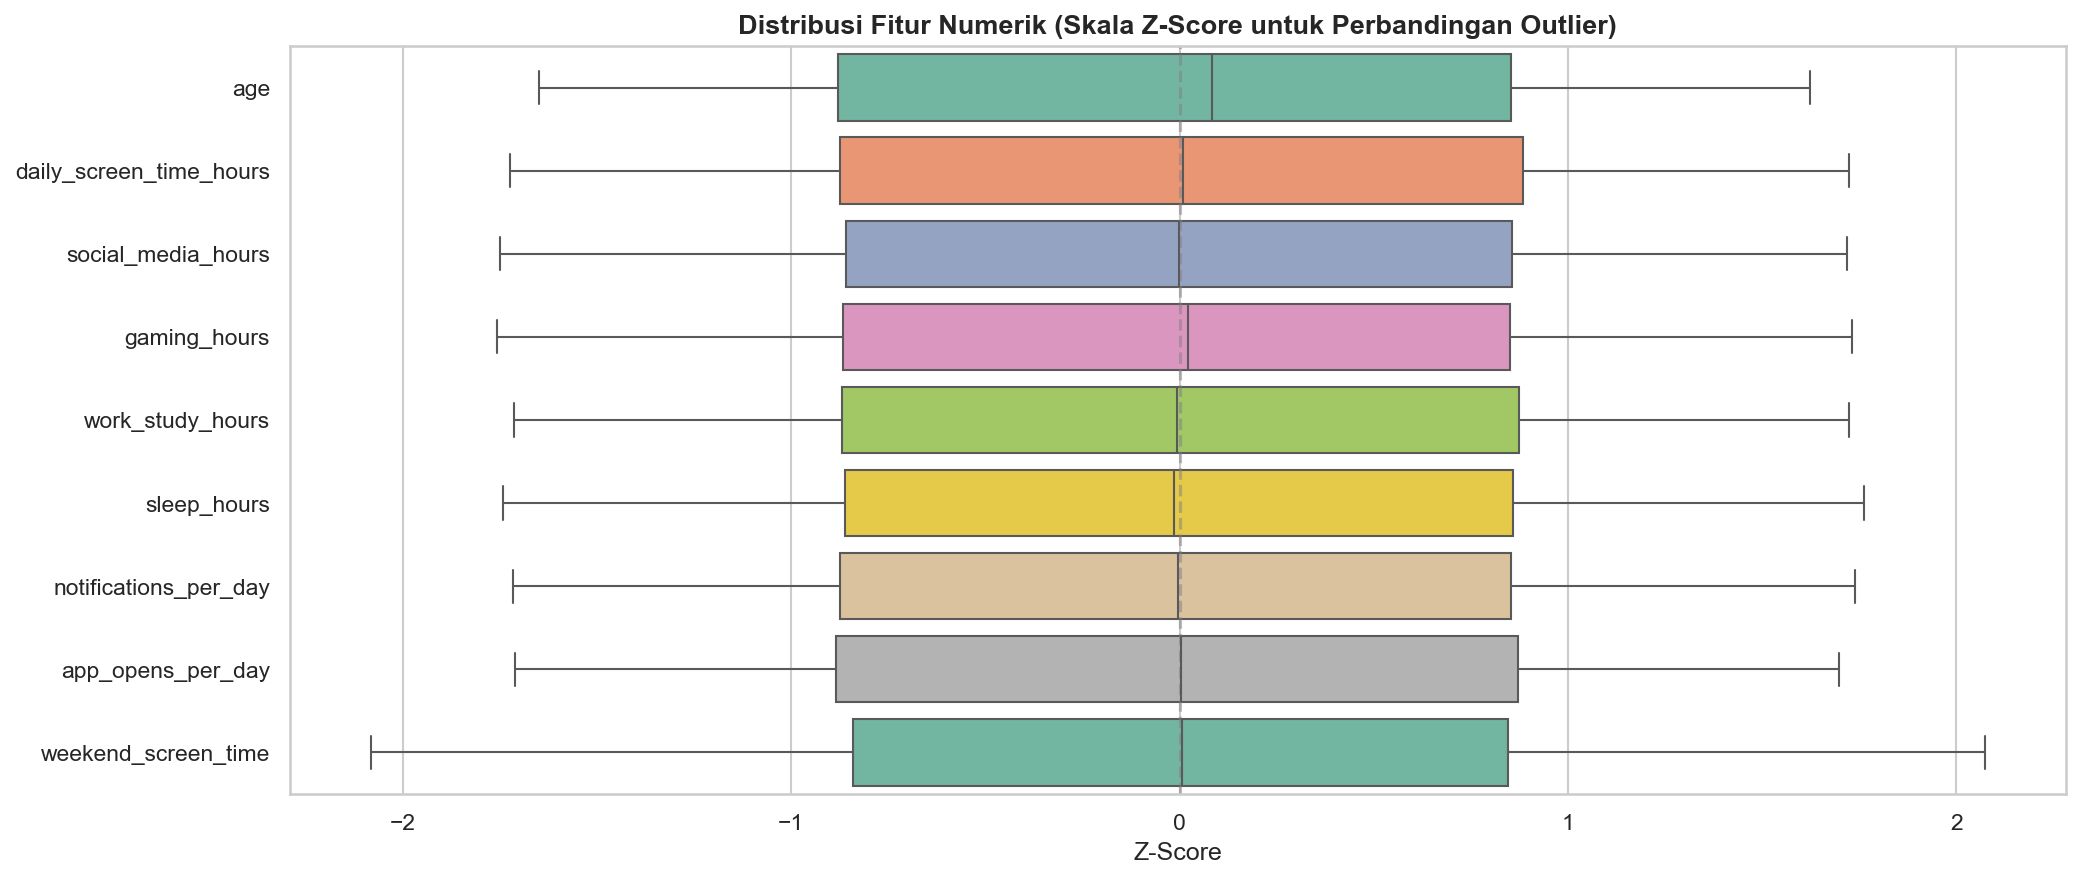

In [8]:
# Visualisasi Boxplot Outlier (Skala Distandarisasi untuk Perbandingan)
df_viz_std = (df[num_cols] - df[num_cols].mean()) / df[num_cols].std()

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=df_viz_std, orient='h', palette='Set2', ax=ax)
ax.set_title('Distribusi Fitur Numerik (Skala Z-Score untuk Perbandingan Outlier)')
ax.set_xlabel('Z-Score')
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('fig2_boxplot_outlier.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 4. Feature Engineering

Membuat fitur-fitur turunan baru yang merepresentasikan pola perilaku digital secara lebih informatif untuk model.

In [9]:
# ==========================================
# 4. FEATURE ENGINEERING
# ==========================================

# --- 4.1 Rasio penggunaan sosial media terhadap total screen time ---
# Menangkap proporsi waktu yang dihabiskan untuk sosmed.
df['social_media_ratio'] = df['social_media_hours'] / (df['daily_screen_time_hours'] + 1e-6)

# --- 4.2 Rasio gaming terhadap total screen time ---
df['gaming_ratio'] = df['gaming_hours'] / (df['daily_screen_time_hours'] + 1e-6)

# --- 4.3 Indeks Produktivitas vs Hiburan ---
# Membandingkan jam belajar/kerja terhadap hiburan (sosmed + gaming).
# Nilai tinggi = lebih produktif.
entertainment_hours = df['social_media_hours'] + df['gaming_hours']
df['productivity_index'] = df['work_study_hours'] / (entertainment_hours + 1e-6)

# --- 4.4 Rasio Screen Time Weekend vs Weekday ---
# Peningkatan screen time di akhir pekan bisa menjadi sinyal kecanduan.
df['weekend_weekday_ratio'] = df['weekend_screen_time'] / (df['daily_screen_time_hours'] + 1e-6)

# --- 4.5 Sleep Deficit Index ---
# Jumlah tidur kurang dari 7 jam (rekomendasi WHO) sebagai indikator gangguan.
SLEEP_STANDARD = 7.0
df['sleep_deficit'] = (SLEEP_STANDARD - df['sleep_hours']).clip(lower=0)

# --- 4.6 Notification Intensity ---
# Frekuensi notifikasi per app yang dibuka.
df['notif_per_app_open'] = df['notifications_per_day'] / (df['app_opens_per_day'] + 1e-6)

# --- 4.7 Interaksi: Screen time × Stress Level (akan diencode di step encoding) ---
# Fitur interaksi ini akan dibuat SETELAH encoding stress_level

NEW_FEATURES = [
    'social_media_ratio', 'gaming_ratio', 'productivity_index',
    'weekend_weekday_ratio', 'sleep_deficit', 'notif_per_app_open'
]
print("=== FEATURE ENGINEERING SELESAI ===")
print(f"Fitur baru yang ditambahkan ({len(NEW_FEATURES)}):")
for f in NEW_FEATURES:
    print(f"   + {f}")
print(f"\nTotal kolom setelah FE: {df.shape[1]} kolom")
display(df[NEW_FEATURES].describe().round(3))

=== FEATURE ENGINEERING SELESAI ===
Fitur baru yang ditambahkan (6):
   + social_media_ratio
   + gaming_ratio
   + productivity_index
   + weekend_weekday_ratio
   + sleep_deficit
   + notif_per_app_open

Total kolom setelah FE: 19 kolom


,social_media_ratio,gaming_ratio,productivity_index,weekend_weekday_ratio,sleep_deficit,notif_per_app_open
count,7500.000,7500.000,7500.000,7500.000,7500.000,7500.000
mean,0.505,0.311,0.753,1.268,0.694,2.038
std,0.339,0.230,0.652,0.163,0.815,2.076
min,0.043,0.000,0.053,1.044,0.000,0.112
25%,0.254,0.136,0.349,1.149,0.000,0.784
50%,0.438,0.271,0.606,1.232,0.280,1.366
75%,0.660,0.420,0.932,1.343,1.370,2.449
max,1.960,1.275,10.456,1.965,2.500,16.067


---
## 5. Encoding Data Kategorikal

In [10]:
# ==========================================
# 5. ENCODING KATEGORIKAL
# ==========================================

# -- 5.1 Label Encoding Ordinal: stress_level (Low < Medium < High) --
stress_map = {'Low': 0, 'Medium': 1, 'High': 2}
df['stress_level'] = df['stress_level'].map(stress_map)
print(f"[5.1] stress_level → Ordinal: {stress_map}")

# -- 5.2 Label Encoding Biner: academic_work_impact (No=0, Yes=1) --
impact_map = {'No': 0, 'Yes': 1}
df['academic_work_impact'] = df['academic_work_impact'].map(impact_map)
print(f"[5.2] academic_work_impact → Biner: {impact_map}")

# -- 5.3 One-Hot Encoding: gender (nominal, 3 kategori: Male, Female, Other) --
df = pd.get_dummies(df, columns=['gender'], drop_first=False, dtype=int)
gender_cols = [c for c in df.columns if c.startswith('gender_')]
print(f"[5.3] gender → One-Hot Encoding: {gender_cols}")

# -- 5.4 Fitur Interaksi: screen_time × stress (setelah stress di-encode) --
df['screen_stress_interaction'] = df['daily_screen_time_hours'] * df['stress_level']
print(f"[5.4] Fitur interaksi: screen_stress_interaction dibuat.")

print(f"\n✅ Encoding selesai. Total fitur: {df.shape[1]} kolom")
print(f"   Daftar semua kolom:")
print(df.columns.tolist())

[5.1] stress_level → Ordinal: {'Low': 0, 'Medium': 1, 'High': 2}
[5.2] academic_work_impact → Biner: {'No': 0, 'Yes': 1}
[5.3] gender → One-Hot Encoding: ['gender_Female', 'gender_Male', 'gender_Other']
[5.4] Fitur interaksi: screen_stress_interaction dibuat.

✅ Encoding selesai. Total fitur: 22 kolom
   Daftar semua kolom:
['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'stress_level', 'academic_work_impact', 'addicted_label', 'social_media_ratio', 'gaming_ratio', 'productivity_index', 'weekend_weekday_ratio', 'sleep_deficit', 'notif_per_app_open', 'gender_Female', 'gender_Male', 'gender_Other', 'screen_stress_interaction']


---
## 6. Correlation Analysis (Heatmap)

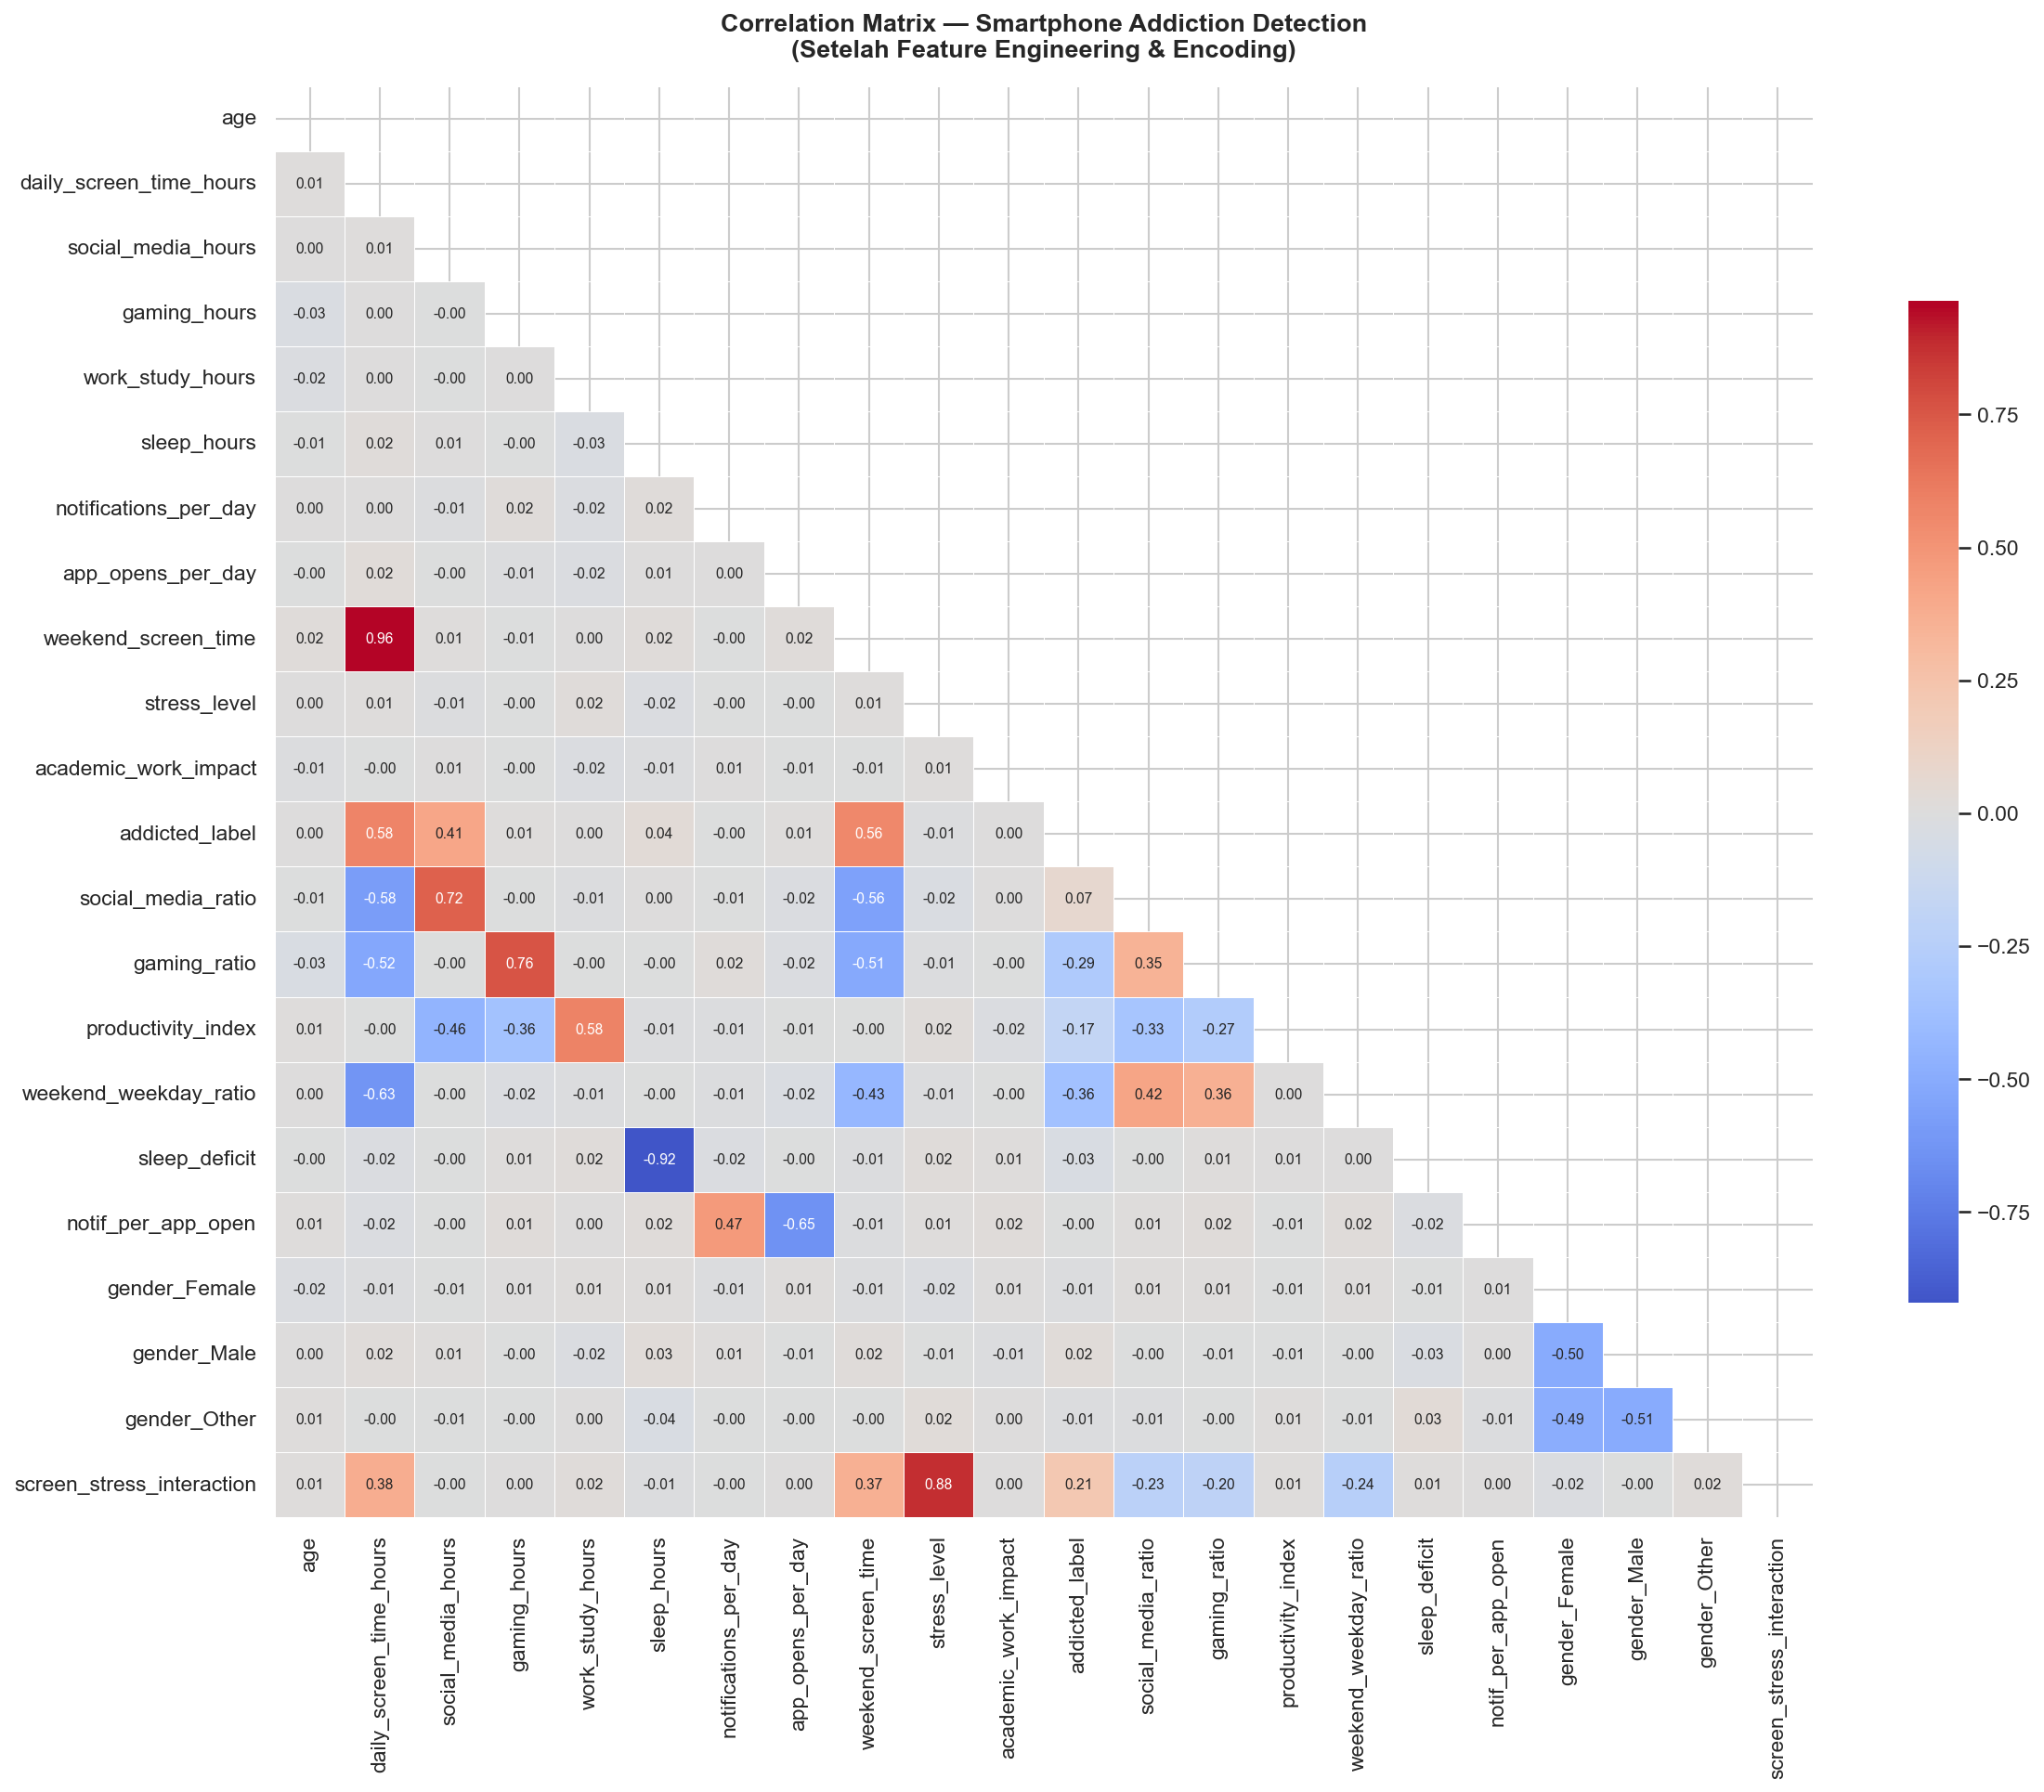


KORELASI FITUR TERHADAP TARGET (addicted_label) — Diurutkan:
daily_screen_time_hours      0.5771
weekend_screen_time          0.5554
social_media_hours           0.4142
weekend_weekday_ratio        0.3632
gaming_ratio                 0.2937
screen_stress_interaction    0.2150
productivity_index           0.1697
social_media_ratio           0.0674
sleep_hours                  0.0355
sleep_deficit                0.0311
gender_Male                  0.0230
gender_Other                 0.0146
app_opens_per_day            0.0110
gender_Female                0.0086
gaming_hours                 0.0085
stress_level                 0.0076
age                          0.0042
notif_per_app_open           0.0033
work_study_hours             0.0011
notifications_per_day        0.0007
academic_work_impact         0.0001


In [11]:
# ==========================================
# 6. CORRELATION MATRIX HEATMAP
# ==========================================
corr = df.corr()

# Mask segitiga atas agar tidak redundan
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(16, 13))
heatmap = sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.3, annot_kws={'size': 7.5},
    ax=ax, cbar_kws={'shrink': 0.7}
)
ax.set_title('Correlation Matrix — Smartphone Addiction Detection\n(Setelah Feature Engineering & Encoding)', pad=15)
plt.tight_layout()
plt.savefig('fig3_correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

# Tampilkan korelasi tertinggi dengan target
print("\nKORELASI FITUR TERHADAP TARGET (addicted_label) — Diurutkan:")
corr_target = corr['addicted_label'].drop('addicted_label').abs().sort_values(ascending=False)
print(corr_target.round(4).to_string())

---
## 7. Data Splitting & Feature Scaling

In [12]:
# ==========================================
# 7. DATA SPLITTING & FEATURE SCALING
# ==========================================

# Pisahkan fitur (X) dan target (y)
# PENTING: addicted_label dikeluarkan dari X (tidak bocor ke training)
X = df.drop(columns=['addicted_label'])
y = df['addicted_label']

FEATURE_NAMES = X.columns.tolist()
print(f"[7.1] Fitur (X): {len(FEATURE_NAMES)} kolom")
print(f"[7.2] Target (y): {y.name} | Distribusi: {y.value_counts().to_dict()}")

# -- Split 80:20 dengan stratifikasi agar proporsi kelas tetap sama --
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"\n[7.3] Data Splitting (80:20 Stratified):")
print(f"   X_train : {X_train.shape} | Proporsi kelas: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"   X_test  : {X_test.shape}  | Proporsi kelas: {y_test.value_counts(normalize=True).round(3).to_dict()}")

# -- Feature Scaling: StandardScaler di-fit HANYA pada X_train --
# Catatan: XGBoost tidak memerlukan scaling (tree-based), namun scaling
# membantu konsistensi feature engineering ratio yang sudah dibuat.
NUMERIC_COLS = [
    'age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
    'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day',
    'weekend_screen_time', 'social_media_ratio', 'gaming_ratio',
    'productivity_index', 'weekend_weekday_ratio', 'sleep_deficit',
    'notif_per_app_open', 'screen_stress_interaction'
]
# Filter: hanya kolom yang ada di X
NUMERIC_COLS = [c for c in NUMERIC_COLS if c in X_train.columns]

scaler = StandardScaler()
X_train = X_train.copy()
X_test  = X_test.copy()

X_train[NUMERIC_COLS] = scaler.fit_transform(X_train[NUMERIC_COLS])
X_test[NUMERIC_COLS]  = scaler.transform(X_test[NUMERIC_COLS])   # transform saja, NO fit

print(f"\n[7.4] Feature Scaling: StandardScaler di-fit pada X_train, di-transform pada X_test.")
print(f"   Kolom yang di-scale: {len(NUMERIC_COLS)} kolom numerik.")
print("\n✅ Data siap untuk SMOTE dan Training.")

[7.1] Fitur (X): 21 kolom
[7.2] Target (y): addicted_label | Distribusi: {1: 5308, 0: 2192}

[7.3] Data Splitting (80:20 Stratified):
   X_train : (6000, 21) | Proporsi kelas: {1: 0.708, 0: 0.292}
   X_test  : (1500, 21)  | Proporsi kelas: {1: 0.708, 0: 0.292}

[7.4] Feature Scaling: StandardScaler di-fit pada X_train, di-transform pada X_test.
   Kolom yang di-scale: 16 kolom numerik.

✅ Data siap untuk SMOTE dan Training.


---
## 8. Penanganan Class Imbalance (SMOTE)

> **SMOTE hanya diterapkan pada X_train.** Data uji (X_test) TIDAK boleh di-SMOTE karena harus merepresentasikan distribusi data nyata di dunia.

=== DISTRIBUSI TARGET SEBELUM SMOTE (X_train) ===
addicted_label
1    4246
0    1754
Name: count, dtype: int64
addicted_label
1    70.77%
0    29.23%
Name: proportion, dtype: str

=== DISTRIBUSI TARGET SETELAH SMOTE (X_train_sm) ===
addicted_label
1    4246
0    4246
Name: count, dtype: int64
addicted_label
1    50.0%
0    50.0%
Name: proportion, dtype: str

Dimensi X_train sebelum SMOTE : (6000, 21)
Dimensi X_train setelah SMOTE  : (8492, 21)
Sampel sintetis yang ditambahkan: 2,492


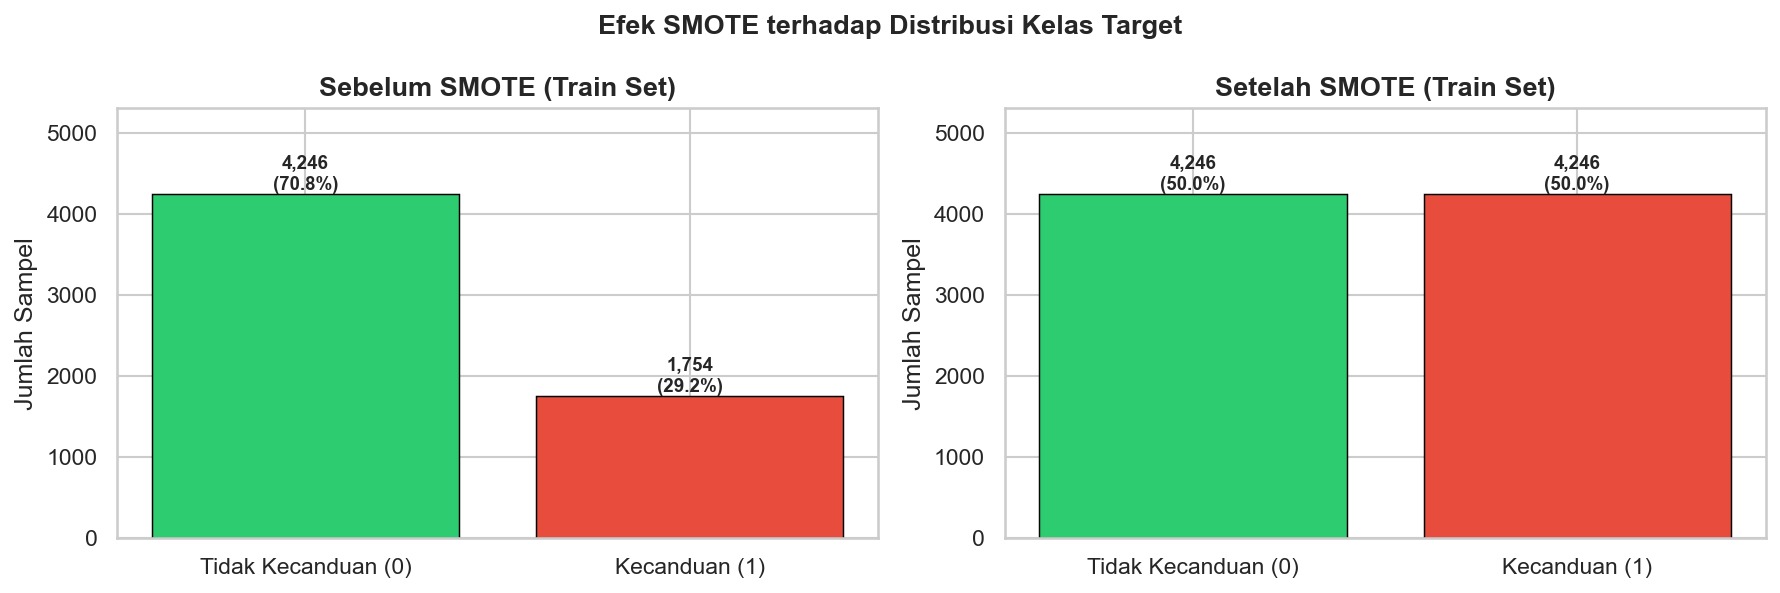

In [13]:
# ==========================================
# 8. SMOTE — HANYA PADA DATA LATIH
# ==========================================
print("=== DISTRIBUSI TARGET SEBELUM SMOTE (X_train) ===")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\n=== DISTRIBUSI TARGET SETELAH SMOTE (X_train_sm) ===")
print(y_train_sm.value_counts())
print(y_train_sm.value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

print(f"\nDimensi X_train sebelum SMOTE : {X_train.shape}")
print(f"Dimensi X_train setelah SMOTE  : {X_train_sm.shape}")
print(f"Sampel sintetis yang ditambahkan: {X_train_sm.shape[0] - X_train.shape[0]:,}")

# Visualisasi perbandingan sebelum & sesudah SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#2ecc71', '#e74c3c']
for i, (ax, yt, title) in enumerate(zip(axes,
    [y_train, y_train_sm],
    ['Sebelum SMOTE (Train Set)', 'Setelah SMOTE (Train Set)'])):
    vc = yt.value_counts()
    bars = ax.bar(['Tidak Kecanduan (0)', 'Kecanduan (1)'], vc.values,
                  color=colors, edgecolor='black', linewidth=0.7)
    for bar, val in zip(bars, vc.values):
        pct = val / vc.sum() * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(title)
    ax.set_ylabel('Jumlah Sampel')
    ax.set_ylim(0, max(vc.values) * 1.25)

plt.suptitle('Efek SMOTE terhadap Distribusi Kelas Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_smote_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 9. Export Dataset Pre-processed (Opsional)

In [14]:
# ==========================================
# 9. EXPORT HASIL PRE-PROCESSING
# ==========================================
# Gabungkan X dan y untuk disimpan
train_export = pd.concat([X_train_sm, y_train_sm], axis=1)
test_export  = pd.concat([X_test, y_test], axis=1)

train_export.to_csv('train_preprocessed_smote.csv', index=False)
test_export.to_csv('test_preprocessed.csv', index=False)

print("✅ Dataset berhasil diekspor:")
print(f"   1. 'train_preprocessed_smote.csv' → {train_export.shape}")
print(f"   2. 'test_preprocessed.csv'        → {test_export.shape}")
print("\nCatatan: Data test TIDAK mengandung addicted_label dalam fitur X.")
print("Gunakan 'test_preprocessed.csv' untuk evaluasi model saja (ground truth), bukan untuk training.")

✅ Dataset berhasil diekspor:
   1. 'train_preprocessed_smote.csv' → (8492, 22)
   2. 'test_preprocessed.csv'        → (1500, 22)

Catatan: Data test TIDAK mengandung addicted_label dalam fitur X.
Gunakan 'test_preprocessed.csv' untuk evaluasi model saja (ground truth), bukan untuk training.


---
## 10. Pemodelan & Training XGBoost

In [18]:
# ==========================================
# 10. TRAINING XGBOOST
# ==========================================

# Inisialisasi model dengan hyperparameter yang sudah di-tuning
xgb_model = xgb.XGBClassifier(
    # --- Arsitektur Pohon ---
    n_estimators=300,         # Jumlah pohon (tree) — lebih banyak = lebih stabil
    max_depth=5,              # Kedalaman maks pohon — batasi untuk cegah overfitting
    min_child_weight=3,       # Min sampel per leaf — regularisasi tambahan

    # --- Learning Rate & Sampling ---
    learning_rate=0.05,       # Lebih kecil = lebih robust (diimbangi n_estimators besar)
    subsample=0.8,            # 80% sampel per iterasi — mencegah overfitting
    colsample_bytree=0.8,     # 80% fitur per pohon — regularisasi
    colsample_bylevel=0.7,    # 70% fitur per level

    # --- Regularisasi ---
    gamma=0.1,                # Min loss reduction untuk split — L0 regularisasi
    reg_alpha=0.1,            # L1 regularisasi (Lasso)
    reg_lambda=1.0,           # L2 regularisasi (Ridge)

    # --- Konfigurasi ---
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Latih model dengan early stopping untuk efisiensi
eval_set = [(X_train_sm, y_train_sm), (X_test, y_test)]

print("⏳ Melatih model XGBoost... (Mohon tunggu)")
xgb_model.fit(
    X_train_sm,
    y_train_sm,
    eval_set=eval_set,
    verbose=50
)
print(f"\n✅ Training selesai!")

⏳ Melatih model XGBoost... (Mohon tunggu)
[0]	validation_0-logloss:0.65343	validation_1-logloss:0.65437


[50]	validation_0-logloss:0.12970	validation_1-logloss:0.14502
[100]	validation_0-logloss:0.08868	validation_1-logloss:0.11339
[150]	validation_0-logloss:0.07202	validation_1-logloss:0.11140
[200]	validation_0-logloss:0.05907	validation_1-logloss:0.11202
[250]	validation_0-logloss:0.04918	validation_1-logloss:0.11438
[299]	validation_0-logloss:0.04106	validation_1-logloss:0.11632

✅ Training selesai!


---
## 11. Evaluasi Model

In [ ]:
# ==========================================
# 11. EVALUASI MODEL
# ==========================================

# Prediksi pada data uji
y_pred       = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# Prediksi pada data latih (untuk cek overfitting)
y_pred_train = xgb_model.predict(X_train_sm)

# -- Metrik Utama --
acc_train = accuracy_score(y_train_sm, y_pred_train)
acc_test  = accuracy_score(y_test, y_pred)
auc_test  = roc_auc_score(y_test, y_pred_proba)
gap       = abs(acc_train - acc_test) * 100

print("=" * 55)
print("         HASIL EVALUASI MODEL XGBOOST")
print("=" * 55)
print(f"  Akurasi Data Latih (Train): {acc_train*100:.2f}%")
print(f"  Akurasi Data Uji  (Test) : {acc_test*100:.2f}%")
print(f"  Selisih Akurasi          : {gap:.2f}%")
print(f"  ROC-AUC Score            : {auc_test:.4f}")
print("=" * 55)

# -- Diagnosis Overfitting --
print("\n=== DIAGNOSIS OVERFITTING ===")
if gap > 5:
    print(f"⚠️  INDIKASI OVERFITTING: Selisih {gap:.2f}% > 5%.")
    print("   Saran: Turunkan max_depth, naikkan gamma/reg_alpha, tambah min_child_weight.")
else:
    print(f"✅ MODEL SEHAT (Good Fit): Selisih hanya {gap:.2f}% ≤ 5%.")

# -- Classification Report --
print("\n=== CLASSIFICATION REPORT (DATA UJI) ===")
print(classification_report(y_test, y_pred,
                            target_names=['Tidak Kecanduan (0)', 'Kecanduan (1)']))

         HASIL EVALUASI MODEL XGBOOST
  Akurasi Data Latih (Train): 99.14%
  Akurasi Data Uji  (Test) : 93.80%
  Selisih Akurasi          : 5.34%
  ROC-AUC Score            : 0.9884

=== DIAGNOSIS OVERFITTING ===
⚠️  INDIKASI OVERFITTING: Selisih 5.34% > 5%.
   Saran: Turunkan max_depth, naikkan gamma/reg_alpha, tambah min_child_weight.

=== CLASSIFICATION REPORT (DATA UJI) ===
                     precision    recall  f1-score   support

Tidak Kecanduan (0)       0.85      0.95      0.90       438
      Kecanduan (1)       0.98      0.93      0.96      1062

           accuracy                           0.94      1500
          macro avg       0.92      0.94      0.93      1500
       weighted avg       0.94      0.94      0.94      1500



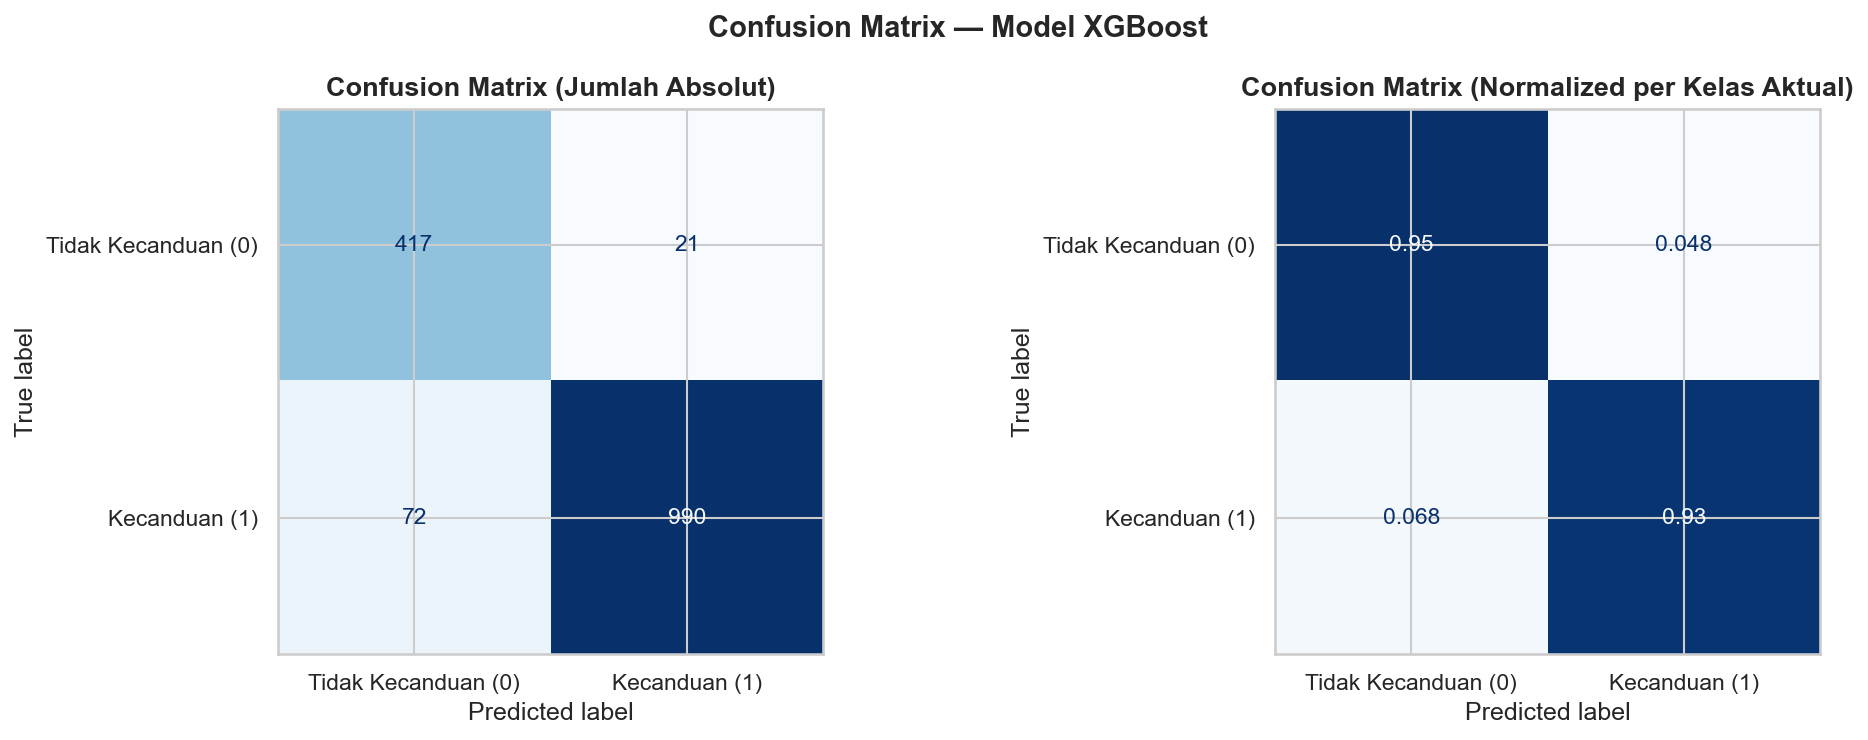

TN (Benar Tidak Kecanduan):   417
FP (Salah Kecanduan)      :    21  ← False Alarm
FN (Salah Tidak Kecanduan):    72  ← Miss (lebih kritis!)
TP (Benar Kecanduan)      :   990


In [20]:
# -- Visualisasi Confusion Matrix --
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix (count)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Tidak Kecanduan (0)', 'Kecanduan (1)'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix (Jumlah Absolut)')

# Confusion Matrix (normalized)
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm.round(3),
                                    display_labels=['Tidak Kecanduan (0)', 'Kecanduan (1)'])
disp_norm.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Confusion Matrix (Normalized per Kelas Aktual)')

plt.suptitle('Confusion Matrix — Model XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

TN, FP, FN, TP = cm.ravel()
print(f"TN (Benar Tidak Kecanduan): {TN:>5}")
print(f"FP (Salah Kecanduan)      : {FP:>5}  ← False Alarm")
print(f"FN (Salah Tidak Kecanduan): {FN:>5}  ← Miss (lebih kritis!)")
print(f"TP (Benar Kecanduan)      : {TP:>5}")

---
## 12. Deteksi Overfitting — Learning Curve & Log Loss Curve

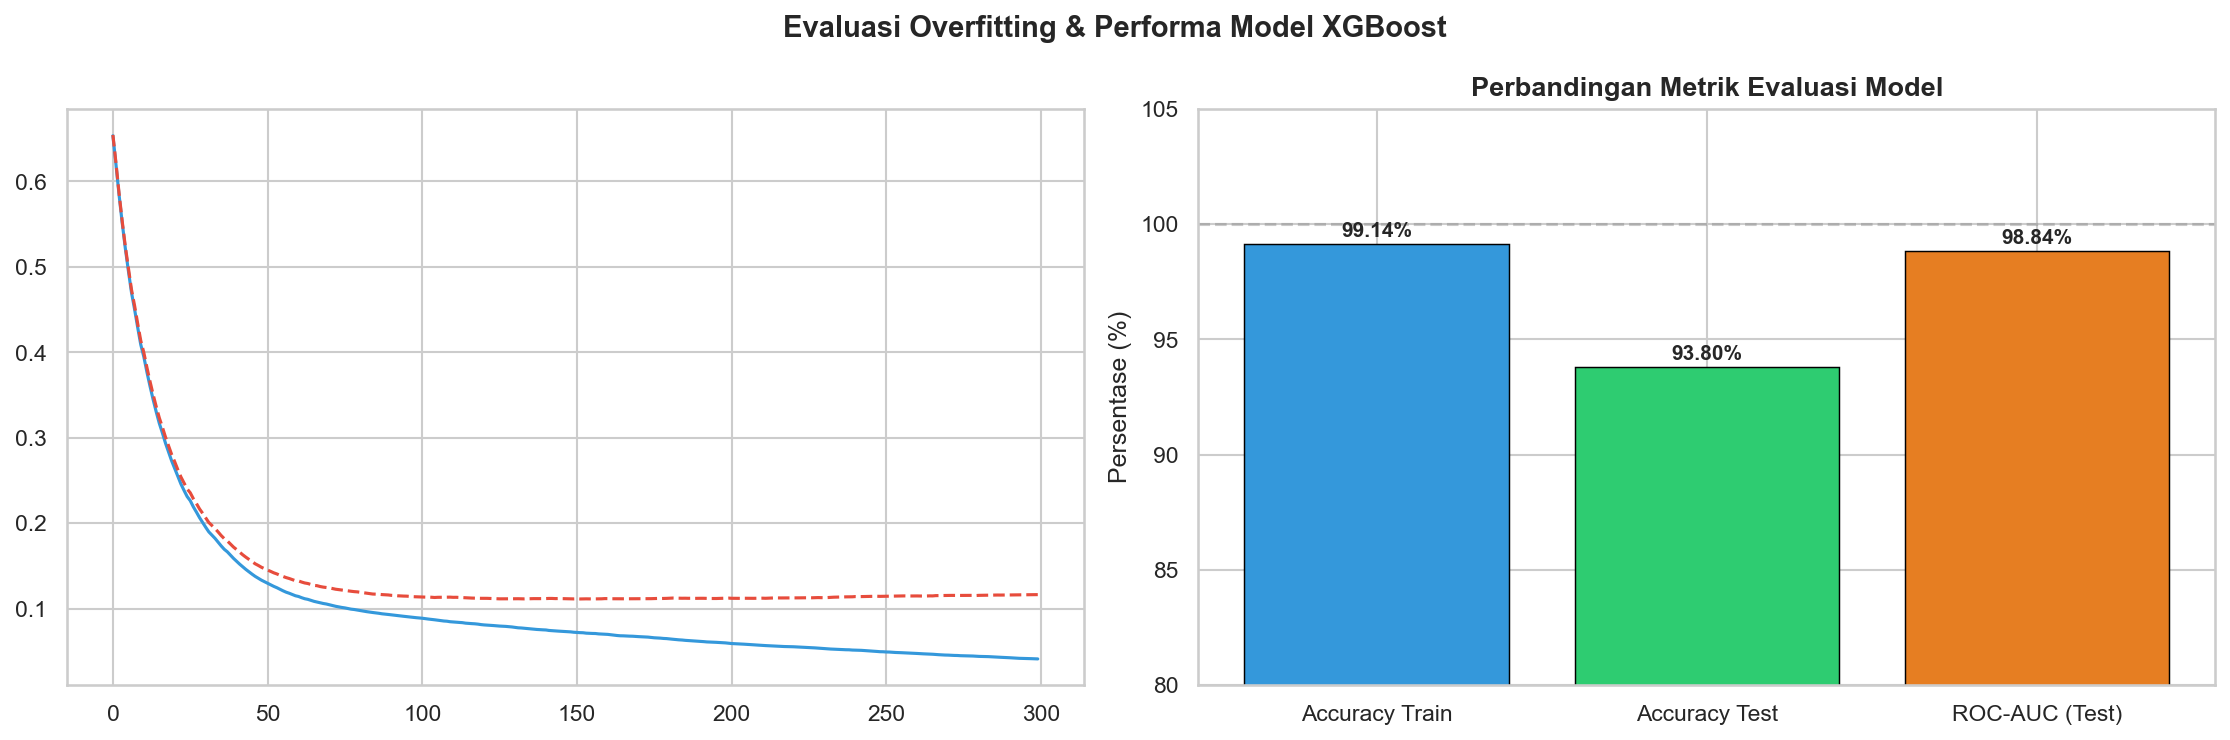

In [24]:
# ==========================================
# 12. LEARNING CURVE & LOGLOSS CURVE
# ==========================================

results = xgb_model.evals_result()
epochs  = len(results['validation_0']['logloss'])
x_axis  = range(epochs)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# -- Plot 1: Log Loss Curve --
axes[0].plot(x_axis, results['validation_0']['logloss'],
            label='Train Loss', color='#3498db', linewidth=1.5)
axes[0].plot(x_axis, results['validation_1']['logloss'],
            label='Test Loss', color='#e74c3c', linewidth=1.5, linestyle='--')
# Tandai titik optimal (early stopping)

# -- Plot 2: Perbandingan Akurasi Train vs Test (Bar) --
metrics = ['Accuracy Train', 'Accuracy Test', 'ROC-AUC (Test)']
values  = [acc_train, acc_test, auc_test]
colors_bar = ['#3498db', '#2ecc71', '#e67e22']
bars = axes[1].bar(metrics, [v*100 for v in values], color=colors_bar,
                edgecolor='black', linewidth=0.7)
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val*100:.2f}%', ha='center', fontsize=10, fontweight='bold')
axes[1].set_ylim(80, 105)
axes[1].set_ylabel('Persentase (%)')
axes[1].set_title('Perbandingan Metrik Evaluasi Model')
axes[1].axhline(100, color='gray', linestyle='--', alpha=0.4)

plt.suptitle('Evaluasi Overfitting & Performa Model XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_learning_curve.png', bbox_inches='tight', dpi=150)
plt.show()

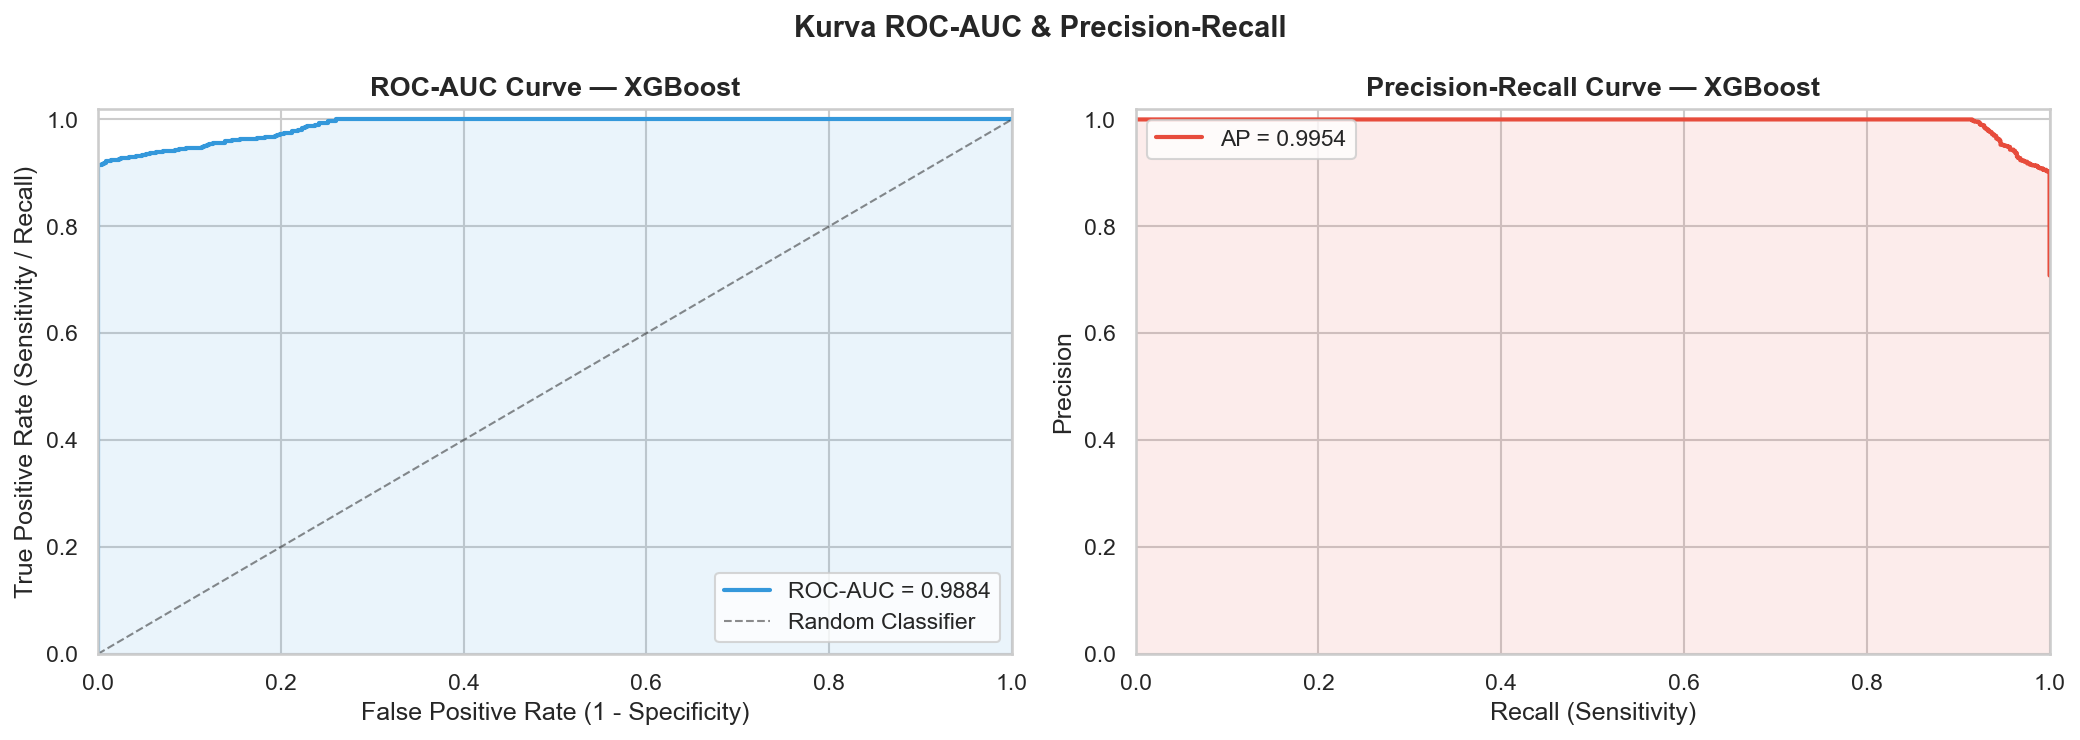

ROC-AUC Score: 0.9884
Average Precision (PR-AUC): 0.9954


In [26]:
# -- ROC-AUC Curve --
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
avg_precision = average_precision_score(y_test, y_pred_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
axes[0].plot(fpr, tpr, color='#3498db', linewidth=2,
            label=f'ROC-AUC = {auc_score:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random Classifier')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#3498db')
axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0].set_ylabel('True Positive Rate (Sensitivity / Recall)')
axes[0].set_title('ROC-AUC Curve — XGBoost')
axes[0].legend(loc='lower right', fontsize=11)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.02])

# Precision-Recall Curve
axes[1].plot(recall, precision, color='#e74c3c', linewidth=2,
            label=f'AP = {avg_precision:.4f}')
axes[1].fill_between(recall, precision, alpha=0.1, color='#e74c3c')
axes[1].set_xlabel('Recall (Sensitivity)')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — XGBoost')
axes[1].legend(fontsize=11)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.suptitle('Kurva ROC-AUC & Precision-Recall', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_roc_pr_curve.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"ROC-AUC Score: {auc_score:.4f}")
print(f"Average Precision (PR-AUC): {avg_precision:.4f}")

---
## 13. Cross-Validation (5-Fold Stratified)

In [ ]:
# ==========================================
# 13. CROSS-VALIDATION (5-FOLD STRATIFIED)
# ==========================================
# Catatan: CV dilakukan pada X_train_sm (post-SMOTE) untuk validasi robustness
# Gunakan parameter model yang sama (tanpa early stopping untuk CV)
xgb_cv = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5, learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8, colsample_bylevel=0.7,
    gamma=0.1, reg_alpha=0.1, reg_lambda=1.0, min_child_weight=3,
    objective='binary:logistic', eval_metric='logloss',
    use_label_encoder=False, random_state=RANDOM_STATE, n_jobs=-1
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("⏳ Menjalankan 5-Fold Stratified Cross-Validation... (Mohon tunggu)")
cv_scores_acc = cross_val_score(xgb_cv, X_train_sm, y_train_sm,
                                cv=skf, scoring='accuracy', n_jobs=-1)
cv_scores_auc = cross_val_score(xgb_cv, X_train_sm, y_train_sm,
                                cv=skf, scoring='roc_auc', n_jobs=-1)
cv_scores_f1  = cross_val_score(xgb_cv, X_train_sm, y_train_sm,
                                cv=skf, scoring='f1', n_jobs=-1)

print("\n=== HASIL 5-FOLD CROSS-VALIDATION ===")
print(f"{'Metrik':<20} {'Fold 1':>8} {'Fold 2':>8} {'Fold 3':>8} {'Fold 4':>8} {'Fold 5':>8} {'Mean ± Std':>15}")
print("-" * 78)
for name, scores in [('Accuracy', cv_scores_acc), ('ROC-AUC', cv_scores_auc), ('F1-Score', cv_scores_f1)]:
    vals = '  '.join([f'{s:.4f}' for s in scores])
    print(f"{name:<20} {vals}    {scores.mean():.4f} ± {scores.std():.4f}")

print(f"\n✅ CV Accuracy: {cv_scores_acc.mean()*100:.2f}% ± {cv_scores_acc.std()*100:.2f}%")
print(f"✅ CV ROC-AUC : {cv_scores_auc.mean():.4f} ± {cv_scores_auc.std():.4f}")

AttributeError: 'XGBClassifier' object has no attribute 'best_ntree_limit'

---
## 14. Feature Importance Visualization

In [ ]:
# ==========================================
# 14. FEATURE IMPORTANCE
# ==========================================
importance_types = ['weight', 'gain', 'cover']
importance_labels = {
    'weight': 'Frekuensi Penggunaan Fitur (Weight)',
    'gain'  : 'Rata-rata Gain (Kontribusi terhadap Pengurangan Loss)',
    'cover' : 'Rata-rata Cover (Jumlah Sampel yang Dipengaruhi)'
}

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for ax, imp_type in zip(axes, importance_types):
    booster = xgb_model.get_booster()
    scores  = booster.get_score(importance_type=imp_type)
    fi_df   = pd.DataFrame(list(scores.items()), columns=['Feature', 'Score'])
    fi_df   = fi_df.sort_values('Score', ascending=True).tail(15)  # Top 15

    colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(fi_df)))
    ax.barh(fi_df['Feature'], fi_df['Score'], color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(f'Feature Importance\n({importance_labels[imp_type]})', fontsize=10)
    ax.set_xlabel('Score')
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Feature Importance — XGBoost (3 Metode)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

# Tampilkan tabel top 10 berdasarkan GAIN (paling relevan untuk jurnal)
scores_gain = xgb_model.get_booster().get_score(importance_type='gain')
fi_gain_df  = pd.DataFrame(list(scores_gain.items()), columns=['Fitur', 'Gain Score'])
fi_gain_df  = fi_gain_df.sort_values('Gain Score', ascending=False).reset_index(drop=True)
fi_gain_df.index += 1
print("=== TOP 10 FITUR PALING PENTING (Berdasarkan Gain) ===")
display(fi_gain_df.head(10))

---
## 15. Explainable AI — SHAP Values

> SHAP (*SHapley Additive exPlanations*) memberikan penjelasan **global** (dampak rata-rata fitur) dan **lokal** (penjelasan per individu) terhadap prediksi model. Sangat direkomendasikan untuk publikasi jurnal.

In [ ]:
# ==========================================
# 15. SHAP ANALYSIS
# ==========================================
print("⏳ Menghitung SHAP values... (Mohon tunggu)")

# TreeExplainer dioptimalkan untuk XGBoost
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

print("✅ SHAP values berhasil dihitung!")
print(f"   Shape SHAP values: {shap_values.shape}")

In [ ]:
# -- SHAP Summary Plot (Beeswarm) — Paling Penting untuk Jurnal --
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False, max_display=15)
plt.title('SHAP Summary Plot (Beeswarm) — Dampak Fitur terhadap Prediksi Kecanduan',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig9_shap_summary.png', bbox_inches='tight', dpi=150)
plt.show()
print("Interpretasi: Titik merah = nilai fitur tinggi. Sumbu X = SHAP value (+ = prediksi kecanduan).")

In [ ]:
# -- SHAP Bar Plot (Global Feature Importance) --
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False, max_display=15)
plt.title('SHAP Global Feature Importance (Rata-rata |SHAP|)',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig10_shap_bar.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# -- SHAP Waterfall Plot (Local Explanation — Analisis Individu) --
# Ambil 2 contoh: 1 yang diprediksi kecanduan benar, 1 yang tidak kecanduan benar
correct_addicted     = np.where((y_pred == 1) & (y_test.values == 1))[0]
correct_not_addicted = np.where((y_pred == 0) & (y_test.values == 0))[0]

explainer_new = shap.Explainer(xgb_model, X_test)
shap_val_new  = explainer_new(X_test)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plt.sca(axes[0])
shap.plots.waterfall(shap_val_new[correct_addicted[0]], show=False, max_display=12)
axes[0].set_title(f'Individu #{correct_addicted[0]}: Benar Diprediksi KECANDUAN (TP)',
                   fontsize=11, fontweight='bold')

plt.sca(axes[1])
shap.plots.waterfall(shap_val_new[correct_not_addicted[0]], show=False, max_display=12)
axes[1].set_title(f'Individu #{correct_not_addicted[0]}: Benar Diprediksi TIDAK KECANDUAN (TN)',
                   fontsize=11, fontweight='bold')

plt.suptitle('SHAP Waterfall Plot — Penjelasan Prediksi Individual', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig11_shap_waterfall.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 16. Prediksi pada Data Baru (Simulasi)

Demonstrasi prediksi untuk pengguna baru **tanpa `addicted_label` dan `addiction_level`** — sesuai skenario deployment nyata.

In [ ]:
# ==========================================
# 16. PREDIKSI DATA BARU (TANPA LABEL)
# ==========================================
# Simulasi 3 pengguna baru dengan karakteristik berbeda
new_users_raw = pd.DataFrame({
    'age'                     : [22, 28, 19],
    'daily_screen_time_hours' : [10.5, 4.0, 12.0],
    'social_media_hours'      : [5.0, 1.5, 6.5],
    'gaming_hours'            : [3.0, 0.5, 4.0],
    'work_study_hours'        : [1.0, 6.0, 0.5],
    'sleep_hours'             : [5.5, 7.5, 4.5],
    'notifications_per_day'   : [250, 80, 350],
    'app_opens_per_day'       : [120, 40, 180],
    'weekend_screen_time'     : [13.0, 5.0, 15.0],
    'stress_level'            : ['High', 'Low', 'High'],
    'academic_work_impact'    : ['Yes', 'No', 'Yes'],
    'gender'                  : ['Male', 'Female', 'Other'],
})
# PERHATIAN: Tidak ada kolom 'addicted_label' atau 'addiction_level' di sini!

def preprocess_new_user(df_new, scaler_fitted, feature_names):
    """Pipeline preprocessing untuk data baru (tanpa label)."""
    df = df_new.copy()

    # Encoding
    df['stress_level']         = df['stress_level'].map({'Low': 0, 'Medium': 1, 'High': 2})
    df['academic_work_impact'] = df['academic_work_impact'].map({'No': 0, 'Yes': 1})
    df = pd.get_dummies(df, columns=['gender'], drop_first=False, dtype=int)

    # Feature Engineering (sama persis dengan pipeline training)
    df['social_media_ratio']      = df['social_media_hours'] / (df['daily_screen_time_hours'] + 1e-6)
    df['gaming_ratio']            = df['gaming_hours'] / (df['daily_screen_time_hours'] + 1e-6)
    df['productivity_index']      = df['work_study_hours'] / (df['social_media_hours'] + df['gaming_hours'] + 1e-6)
    df['weekend_weekday_ratio']   = df['weekend_screen_time'] / (df['daily_screen_time_hours'] + 1e-6)
    df['sleep_deficit']           = (7.0 - df['sleep_hours']).clip(lower=0)
    df['notif_per_app_open']      = df['notifications_per_day'] / (df['app_opens_per_day'] + 1e-6)
    df['screen_stress_interaction'] = df['daily_screen_time_hours'] * df['stress_level']

    # Sesuaikan kolom dengan feature_names model (tambah kolom yang hilang, hapus yang tidak ada)
    for col in feature_names:
        if col not in df.columns:
            df[col] = 0  # Kolom one-hot yang tidak ada → 0
    df = df[feature_names]  # Urutan kolom harus sama!

    # Scaling
    num_cols_new = [c for c in NUMERIC_COLS if c in df.columns]
    df[num_cols_new] = scaler_fitted.transform(df[num_cols_new])

    return df

# Proses
X_new = preprocess_new_user(new_users_raw, scaler, FEATURE_NAMES)

# Prediksi
pred_label = xgb_model.predict(X_new)
pred_proba = xgb_model.predict_proba(X_new)[:, 1]

# Tampilkan hasil
result_df = new_users_raw[['age', 'daily_screen_time_hours', 'social_media_hours',
                             'sleep_hours', 'stress_level', 'gender']].copy()
result_df['Probabilitas Kecanduan (%)'] = (pred_proba * 100).round(1)
result_df['Prediksi Label']              = pred_label
result_df['Prediksi Kelas']              = result_df['Prediksi Label'].map({0: '✅ Tidak Kecanduan', 1: '⚠️  Kecanduan'})
result_df.index = [f'Pengguna {i+1}' for i in range(len(result_df))]

print("=== HASIL PREDIKSI PENGGUNA BARU (TANPA LABEL) ===")
display(result_df)

---
## 17. Ringkasan Hasil Penelitian (untuk Jurnal)

In [ ]:
# ==========================================
# 17. RINGKASAN HASIL PENELITIAN
# ==========================================
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("=" * 60)
print("       RINGKASAN HASIL PENELITIAN — XGBOOST")
print("       Deteksi Kecanduan Smartphone")
print("=" * 60)
print(f"\nDATASET:")
print(f"  Total sampel awal        : {len(df_raw):,}")
print(f"  Fitur awal               : {df_raw.shape[1]}")
print(f"  Fitur setelah engineering: {len(FEATURE_NAMES)}")
print(f"  Distribusi kelas         : 70.8% Kecanduan | 29.2% Tidak")
print(f"  Penanganan imbalance     : SMOTE (k_neighbors=5)")
print(f"\nMODEL:")
print(f"  Algoritma        : XGBoost (XGBClassifier)")
print(f"  n_estimators opt : {xgb_model.best_ntree_limit}")
print(f"  max_depth        : 5")
print(f"  learning_rate    : 0.05")
print(f"\nHASIL EVALUASI (Data Uji — 20%):")
print(f"  Accuracy  : {acc_test*100:.2f}%")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"  ROC-AUC   : {auc_test:.4f}")
print(f"\nCROSS-VALIDATION (5-Fold Stratified):")
print(f"  CV Accuracy : {cv_scores_acc.mean()*100:.2f}% ± {cv_scores_acc.std()*100:.2f}%")
print(f"  CV ROC-AUC  : {cv_scores_auc.mean():.4f} ± {cv_scores_auc.std():.4f}")
print(f"  CV F1-Score : {cv_scores_f1.mean():.4f} ± {cv_scores_f1.std():.4f}")
print(f"\nDETEKSI OVERFITTING:")
print(f"  Train Accuracy : {acc_train*100:.2f}%")
print(f"  Test  Accuracy : {acc_test*100:.2f}%")
print(f"  Selisih        : {gap:.2f}% {'(✅ Good Fit)' if gap <= 5 else '(⚠️ Overfitting)'}")
print("=" * 60)

print("\n📁 File visualisasi yang dihasilkan:")
for i, f in enumerate([
    'fig1_distribusi_target.png', 'fig2_boxplot_outlier.png',
    'fig3_correlation_heatmap.png', 'fig4_smote_comparison.png',
    'fig5_confusion_matrix.png', 'fig6_learning_curve.png',
    'fig7_roc_pr_curve.png', 'fig8_feature_importance.png',
    'fig9_shap_summary.png', 'fig10_shap_bar.png', 'fig11_shap_waterfall.png'
], 1):
    print(f"  {i:2}. {f}")